In [1]:
%pip install uncertainties

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.constants import c, h, e
from scipy.odr import ODR, Model, RealData

from uncertainties import ufloat, correlated_values
from uncertainties import unumpy as unp
from uncertainties import umath


# ============================================================
# PHYSICAL CONSTANTS
# ============================================================

h_ref = h
e_ref = e
h_over_e_ref = h / e

print(f"Reference h/e = {h_over_e_ref:.6e} V s")
print(f"Reference h   = {h_ref:.6e} J s")

Reference h/e = 4.135668e-15 V s
Reference h   = 6.626070e-34 J s


# Experiment Wellenlänge / Unsicherheiten

lambda red: 612.4898408343587 nm
sigma lambda red: 29.377505723163925 nm
lambda yellow: 583.5231388947966 nm
sigma lambda yellow: 29.368290492989836 nm
lambda green: 554.5274251627884 nm
sigma lambda green: 29.35944856881991 nm
lambda blue: 496.45459195700596 nm
sigma lambda blue: 29.342928427504695 nm


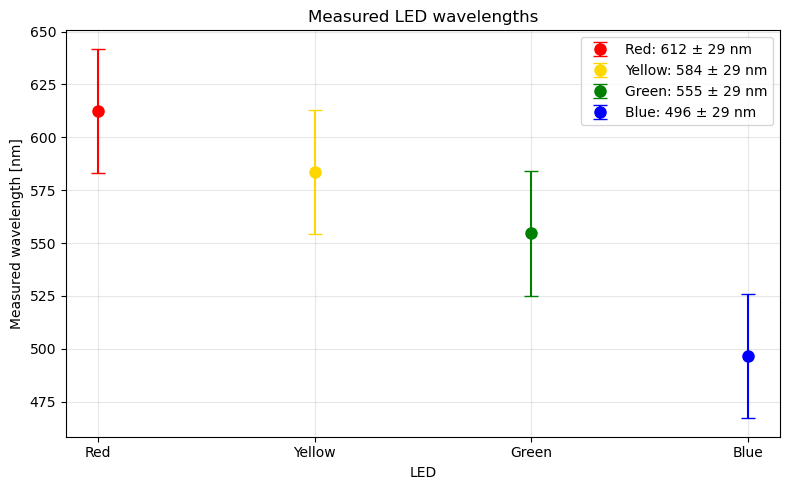

In [18]:
import numpy as np

# Distance between Lens - Grating
a_r = 0.15
a_y = 0.15
a_g = 0.15
a_b = 0.15

# Distance between Grating - Screen
b_r = 0.122
b_y = 0.122
b_g = 0.122
b_b = 0.122

# Distance between central maximum and first order maximum
c_red = 0.021 / 2
c_yellow = 0.02 / 2
c_green = 0.019/2
c_blue = 0.017/2

# Grating
slits_per_mm = 140

# Distance between two slits [m]
g = 1 / (slits_per_mm * 10**3)


def wavelength(c, b, order, g):
    """
    Calculate wavelength from diffraction grating.

    c : distance between central maximum and n-th order maximum [m]
    b : distance grating - screen [m]
    order : diffraction order
    g : grating spacing [m]
    """

    return (g / order) * c / np.sqrt(c**2 + b**2)


# Wavelengths
wave_length_red = wavelength(c_red, b_r, 1.0, g)
wave_length_yellow = wavelength(c_yellow, b_y, 1.0, g)
wave_length_green = wavelength(c_green, b_g, 1, g)
wave_length_blue = wavelength(c_blue, b_b, 1, g)



# -------------------------------------------------
# Uncertainties
# -------------------------------------------------

# Measurement uncertainty
sigma_c = 0.0005   # 1 mm uncertainty for peak distance [m]
sigma_b = 0.001   # 1 mm uncertainty for grating-screen distance [m]


def wavelength_uncertainty(c, b, order, g, sigma_c, sigma_b):

    # Partial derivative with respect to c
    dlambda_dc = (
        (g / order)
        * b**2
        / (c**2 + b**2)**(3/2)
    )

    # Partial derivative with respect to b
    dlambda_db = (
        -(g / order)
        * c * b
        / (c**2 + b**2)**(3/2)
    )

    # Gaussian error propagation
    sigma_lambda = np.sqrt(
        (dlambda_dc * sigma_c)**2
        + (dlambda_db * sigma_b)**2
    )

    return sigma_lambda


sigma_red = wavelength_uncertainty(c_red, b_r, 1, g, sigma_c, sigma_b)

sigma_yellow = wavelength_uncertainty(c_yellow, b_y, 1, g, sigma_c, sigma_b)

sigma_green = wavelength_uncertainty(c_green, b_g, 1, g, sigma_c, sigma_b)

sigma_blue = wavelength_uncertainty(c_blue, b_b, 1, g, sigma_c, sigma_b)

print("lambda red:", wave_length_red * 1e9,'nm')
print("sigma lambda red:", sigma_red * 1e9,'nm')

print("lambda yellow:", wave_length_yellow * 1e9, 'nm')
print("sigma lambda yellow:", sigma_yellow * 1e9, 'nm')

print("lambda green:", wave_length_green * 1e9, 'nm')
print("sigma lambda green:", sigma_green * 1e9, 'nm')

print("lambda blue:", wave_length_blue * 1e9, 'nm')
print("sigma lambda blue:", sigma_blue * 1e9, 'nm')



import os
import numpy as np
import matplotlib.pyplot as plt





led_names = ["Red", "Yellow", "Green", "Blue"]

wavelengths_nm = np.array([
    wave_length_red,
    wave_length_yellow,
    wave_length_green,
    wave_length_blue
]) * 1e9

sigma_wavelengths_nm = np.array([
    sigma_red,
    sigma_yellow,
    sigma_green,
    sigma_blue
]) * 1e9




plt.figure(figsize=(8, 5))

x = np.arange(len(led_names))

colors = ["red", "gold", "green", "blue"]

for i in range(len(led_names)):

    wavelength_rounded = round(wavelengths_nm[i])
    sigma_rounded = round(sigma_wavelengths_nm[i])

    plt.errorbar(
        x[i],
        wavelengths_nm[i],
        yerr=sigma_wavelengths_nm[i],
        fmt="o",
        color=colors[i],
        ecolor=colors[i],
        capsize=5,
        markersize=8,
        label=(
            f"{led_names[i]}: "
            f"{wavelength_rounded} ± {sigma_rounded} nm"
        )
    )

plt.xticks(x, led_names)

plt.xlabel("LED")
plt.ylabel("Measured wavelength [nm]")

plt.title("Measured LED wavelengths")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "Plots/measured_wavelengths.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

# Photostrom Messung

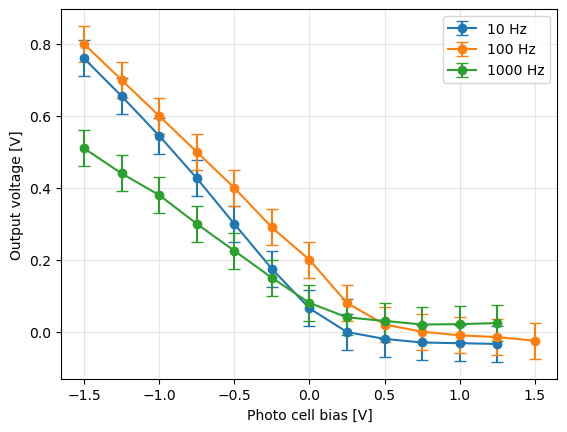

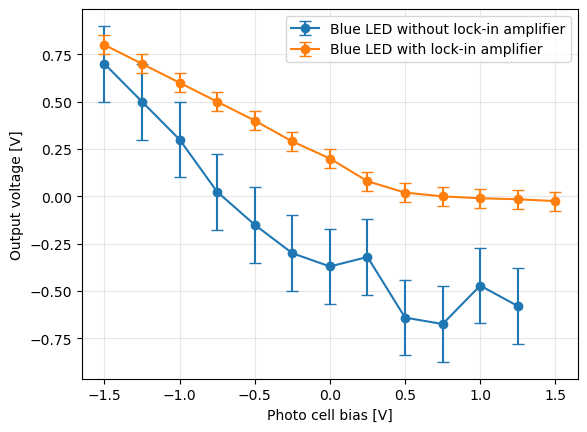

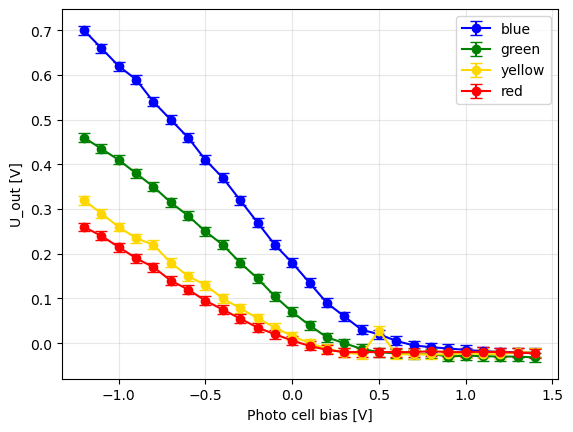

In [19]:
import numpy as np
import matplotlib.pyplot as plt



frequencies = [10, 100, 1000]   # Hz

sigma_dif_freq=0.05

bias_diff_freq = np.arange(-1.5, 1.75, 0.25)

output_100Hz = np.array([
    0.8, 0.7, 0.6, 0.5, 0.4, 0.29, 0.2,
    0.08, 0.02, 0.0, -0.01, -0.015, -0.025
])

bias_diff_freq_2 = np.arange(1.25, -1.75, -0.25)



output_10Hz = np.array([-0.034,-0.032,-0.03,-0.02,-0.001,0.065,0.175,0.3,0.427,0.545,0.655,0.76])

output_1000Hz = np.array([0.024,0.021,0.02,0.03,0.04,0.08,0.15,0.225,0.3,0.38,0.44,0.51])      

plt.errorbar(bias_diff_freq_2 , output_10Hz,yerr=sigma_dif_freq,fmt='o-',capsize=4, label="10 Hz")

plt.errorbar(bias_diff_freq , output_100Hz,yerr=sigma_dif_freq,fmt='o-',capsize=4,label="100 Hz")

plt.errorbar(bias_diff_freq_2 , output_1000Hz,yerr=sigma_dif_freq,fmt='o-',capsize=4,label="1000 Hz")

plt.xlabel("Photo cell bias [V]")
plt.ylabel("Output voltage [V]")


plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig(
    "Plots/Diffrent_frequencies.png",
    dpi=180,
    bbox_inches="tight"
)
plt.show()




bias_no_lockin = np.arange(-1.5, 1.5, 0.25)

# Measured with oscilloscope
output_no_lockin = np.array([0.7,0.5,0.3,0.024,-0.15,-0.3,-0.37,-0.32,-0.64,-0.674,-0.471,-0.579])
sigma_nolockin=0.2
plt.errorbar(bias_no_lockin , output_no_lockin,yerr=sigma_nolockin,fmt='o-',capsize=4, label="Blue LED without lock-in amplifier")
plt.errorbar(bias_diff_freq , output_100Hz,yerr=sigma_dif_freq,fmt='o-',capsize=4,label="Blue LED with lock-in amplifier")
plt.xlabel("Photo cell bias [V]")
plt.ylabel("Output voltage [V]")

plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig(
    "Plots/without_lockin.png",
    dpi=180,
    bbox_inches="tight"
)
plt.show()
plt.show()



sigma_01steps = 0.01
# Example steps of 0.1 V
bias = np.arange(-1.2, 1.5, 0.1)

# Measured output voltages for each LED
output_blue = np.array([0.7,0.66,0.62,0.59,0.54,0.5,0.46, 0.41,0.37, 
                       0.32, 0.27, 0.22, 0.18,0.135, 0.09, 0.06, 0.03,
                       0.02,0.005, -0.005,-0.009,-0.012, -0.015,-0.018,-0.02,-0.02,-0.021])
output_green = np.array([0.46, 0.435, 0.41, 0.38, 0.35, 0.315, 0.285, 0.25, 0.22, 0.18,
                         0.145, 0.105, 0.07, 0.04, 0.013, 0.000, -0.013, -0.02,
                         -0.023, -0.025,-0.024, -0.03,-0.028, -0.029, -0.03, -0.03,-0.032])



output_red = np.array([0.26, 0.24, 0.215, 0.19, 0.17, 0.14, 0.12,0.095, 0.075, 0.055, 0.035, 0.02, 0.0058, -0.0062,-0.015, -0.02, -0.0200, -0.0200, -0.0200, -0.0200,-0.018, -0.0200, -0.0200, -0.019, -0.020, -0.021,-0.023])


output_yellow = np.array([0.32, 0.29, 0.26, 0.235, 0.22, 0.18, 0.15,0.13, 0.1, 0.078, 0.056, 0.035, 0.0160, 0.0001,-0.0125, -0.021, -0.025, 0.0280, -0.0250, -0.0250,-0.0250, -0.0250, -0.023, -0.024, -0.0250, -0.020,-0.0210])



def voltage_to_photocurrent(U_out):
    I_photo = U_out/10   # [nA], preliminary
    return I_photo


I_red = voltage_to_photocurrent(output_red)
I_yellow = voltage_to_photocurrent(output_yellow)
I_green = voltage_to_photocurrent(output_green)
I_blue = voltage_to_photocurrent(output_blue)




plt.errorbar(bias, output_blue, yerr=sigma_01steps,fmt='o-',capsize=4,color='blue', label="blue")
plt.errorbar(bias, output_green, yerr=sigma_01steps,fmt='o-',capsize=4, color= 'green', label="green")
plt.errorbar(bias, output_yellow, yerr=sigma_01steps,fmt='o-',capsize=4, color= 'gold', label="yellow")
plt.errorbar(bias, output_red, yerr=sigma_01steps,fmt='o-',capsize=4, color= 'red', label="red")

plt.xlabel("Photo cell bias [V]")
plt.ylabel("U_out [V]")
plt.legend()
plt.savefig(
    "Plots/All_LED_dv_01.png",
    dpi=180,
    bbox_inches="tight"
)
plt.grid(True, alpha=0.3)
plt.show()

# Relative Itensität des LED

Spectral response:
Red    : lambda = (612.5 +/- 29.4) nm, R = 0.000311
Yellow : lambda = (583.5 +/- 29.4) nm, R = 0.005624
Green  : lambda = (554.5 +/- 29.4) nm, R = 0.030839
Blue   : lambda = (496.5 +/- 29.3) nm, R = 0.165494


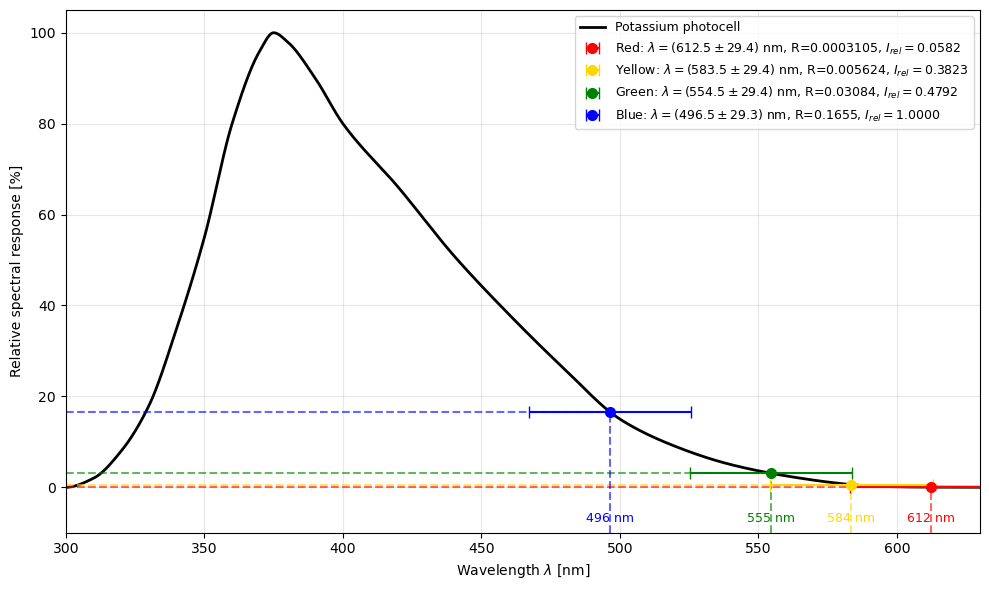


Corrected relative intensities (Blue = 1):
Red:    0.0582
Yellow: 0.3823
Green:  0.4792
Blue:   1.0000


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator




wavelengths_nm = np.array([
    wave_length_red,
    wave_length_yellow,
    wave_length_green,
    wave_length_blue
]) * 1e9

names = ["Red", "Yellow", "Green", "Blue"]
colors = ["red", "gold", "green", "blue"]



lambda_curve = np.array([
    300, 310, 320, 330, 340,
    350, 360, 370, 375, 380,
    390, 400, 420, 440, 460,
    480, 500, 520, 540, 560,
    580
])

response_curve = np.array([
    0.00, 0.02, 0.08, 0.18, 0.35,
    0.55, 0.80, 0.96, 1.00, 0.98,
    0.90, 0.80, 0.66, 0.51, 0.38,
    0.26, 0.15, 0.09, 0.05, 0.025,
    0.008
])



interpolation = PchipInterpolator(
    lambda_curve,
    response_curve,
    extrapolate=False
)


def spectral_response(wavelength_nm):

    wavelength_nm = np.asarray(wavelength_nm, dtype=float)

    response = np.zeros_like(wavelength_nm)

    # Interpolated region
    mask_normal = wavelength_nm <= 580

    response[mask_normal] = interpolation(
        wavelength_nm[mask_normal]
    )

    # Exponential tail
    mask_tail = wavelength_nm > 580

    R_580 = 0.008
    tau = 10.0

    response[mask_tail] = R_580 * np.exp(
        -(wavelength_nm[mask_tail] - 580) / tau
    )

    return response


R = spectral_response(wavelengths_nm)

R_red = R[0]
R_yellow = R[1]
R_green = R[2]
R_blue = R[3]


U_red = output_red[12]
U_yellow = output_yellow[12]
U_green = output_green[12]
U_blue = output_blue[12]


I_red = U_red / R_red
I_yellow = U_yellow / R_yellow
I_green = U_green / R_green
I_blue = U_blue / R_blue


Irel_red = I_blue / I_red
Irel_yellow = I_blue / I_yellow
Irel_green = I_blue / I_green
Irel_blue = 1.0

Irel = np.array([
    Irel_red,
    Irel_yellow,
    Irel_green,
    Irel_blue
])

print("Spectral response:")

for i in range(4):

    print(
        f"{names[i]:7s}: "
        f"lambda = ({wavelengths_nm[i]:.1f} +/- "
        f"{sigma_wavelengths_nm[i]:.1f}) nm, "
        f"R = {R[i]:.6f}"
    )


lambda_plot = np.linspace(300, 630, 1500)

response_plot = spectral_response(lambda_plot)


plt.figure(figsize=(10, 6))


# Spectral response curve
plt.plot(
    lambda_plot,
    response_plot * 100,
    color="black",
    linewidth=2,
    label="Potassium photocell"
)


for i in range(4):

    wavelength = wavelengths_nm[i]
    sigma_wavelength = sigma_wavelengths_nm[i]

    response = R[i]

    name = names[i]
    color = colors[i]



    plt.errorbar(
        wavelength,
        response * 100,
        xerr=sigma_wavelength,
        fmt="o",
        color=color,
        markersize=7,
        capsize=4,
        zorder=5,

        label=(
            f"{name}: "
            rf"$\lambda=({wavelength:.1f}\pm{sigma_wavelength:.1f})$ nm, "
            f"R={response:.4g}, "
            rf"$I_{{rel}}={Irel[i]:.4f}$"
        )
    )



    plt.vlines(
        wavelength,
        -10,
        response * 100,
        color=color,
        linestyle="--",
        alpha=0.6
    )


    plt.hlines(
        response * 100,
        300,
        wavelength,
        color=color,
        linestyle="--",
        alpha=0.6
    )


    plt.annotate(
        f"{wavelength:.0f} nm",
        (wavelength, 0),
        xytext=(0, -18),
        textcoords="offset points",
        ha="center",
        va="top",
        color=color,
        fontsize=9
    )


plt.xlabel(r"Wavelength $\lambda$ [nm]")
plt.ylabel("Relative spectral response [%]")

plt.xlim(300, 630)
plt.ylim(-10, 105)

plt.grid(alpha=0.3)

plt.legend(
    loc="upper right",
    fontsize=9
)

plt.tight_layout()
plt.savefig(
    "Plots/Relativ_I_blue.png",
    dpi=180,
    bbox_inches="tight"
)
plt.show()

print("\nCorrected relative intensities (Blue = 1):")

print(f"Red:    {Irel_red:.4f}")
print(f"Yellow: {Irel_yellow:.4f}")
print(f"Green:  {Irel_green:.4f}")
print(f"Blue:   {Irel_blue:.4f}")

# Reversed Current

I_reverse red = -0.0021 ± 0.0002 nA
I_reverse yellow = -0.0023 ± 0.0002 nA
I_reverse green = -0.0030 ± 0.0001 nA
I_reverse blue = -0.0019 ± 0.0002 nA


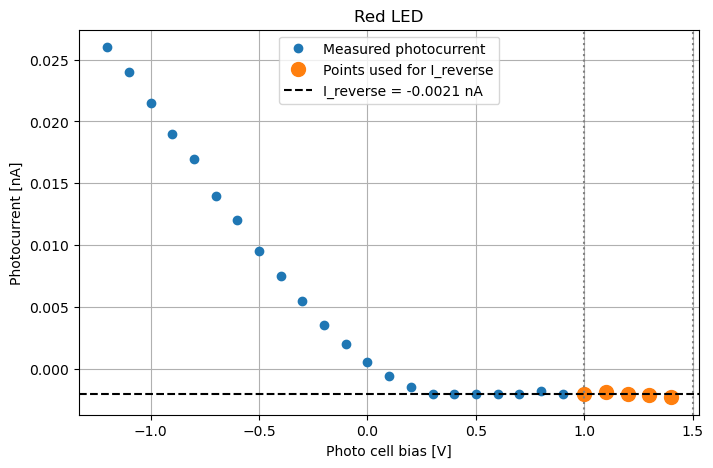

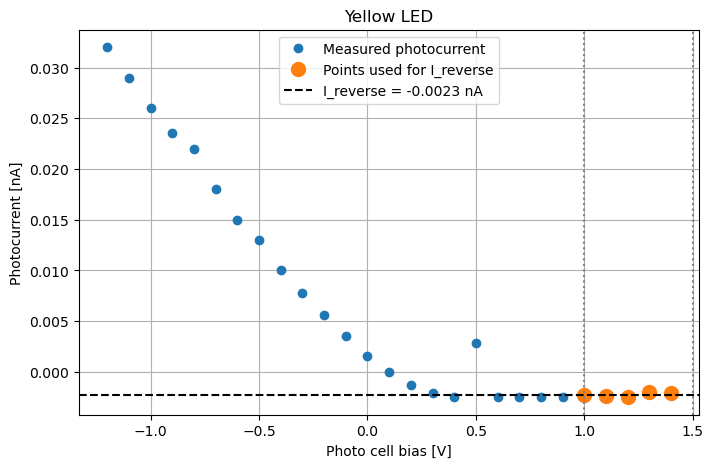

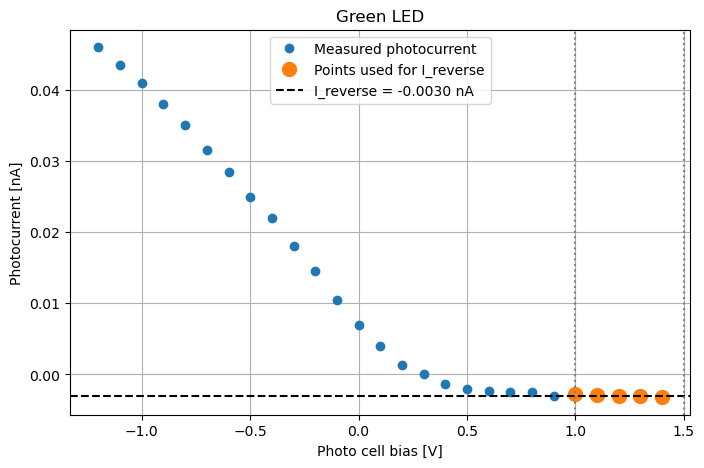

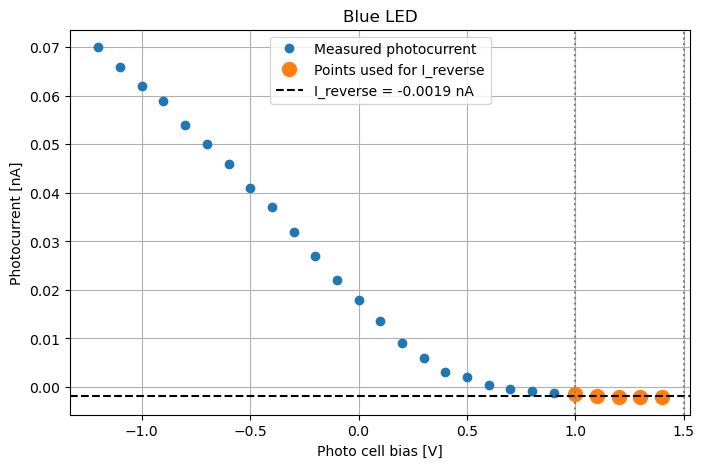

In [28]:
import numpy as np
import matplotlib.pyplot as plt


U_bias = bias


I_red = output_red / 10
I_yellow = output_yellow / 10
I_green = output_green / 10
I_blue = output_blue / 10


# Red
U_min_red = 1
U_max_red = 1.5

# Yellow
U_min_yellow = 1
U_max_yellow = 1.5

# Green
U_min_green = 1
U_max_green = 1.5

# Blue
U_min_blue = 1
U_max_blue = 1.5



def get_reverse_current(U_bias, I_photo, U_min, U_max):

    mask = (
        (U_bias >= U_min) &
        (U_bias <= U_max)
    )

    I_reverse = np.mean(I_photo[mask])

    sigma_I_reverse = np.std(
        I_photo[mask],
        ddof=1
    )

    return I_reverse, sigma_I_reverse, mask


# --------------------------------------------------
# Reverse currents berechnen
# --------------------------------------------------

I_reverse_red, sigma_reverse_red, mask_red = get_reverse_current(
    U_bias, I_red, U_min_red, U_max_red
)

I_reverse_yellow, sigma_reverse_yellow, mask_yellow = get_reverse_current(
    U_bias, I_yellow, U_min_yellow, U_max_yellow
)

I_reverse_green, sigma_reverse_green, mask_green = get_reverse_current(
    U_bias, I_green, U_min_green, U_max_green
)

I_reverse_blue, sigma_reverse_blue, mask_blue = get_reverse_current(
    U_bias, I_blue, U_min_blue, U_max_blue
)


print(f"I_reverse red = {I_reverse_red:.4f} ± {sigma_reverse_red:.4f} nA")
print(f"I_reverse yellow = {I_reverse_yellow:.4f} ± {sigma_reverse_yellow:.4f} nA")
print(f"I_reverse green = {I_reverse_green:.4f} ± {sigma_reverse_green:.4f} nA")
print(f"I_reverse blue = {I_reverse_blue:.4f} ± {sigma_reverse_blue:.4f} nA")


def plot_reverse_current(
    U_bias,
    I_photo,
    mask,
    I_reverse,
    U_min,
    U_max,
    name
):

    plt.figure(figsize=(8,5))

    
    plt.plot(
        U_bias,
        I_photo,
        "o",
        label="Measured photocurrent"
    )

    
    plt.plot(
        U_bias[mask],
        I_photo[mask],
        "o",
        markersize=10,
        label="Points used for I_reverse"
    )

    plt.axhline(
        I_reverse,
        color="black",
        linestyle="--",
        label=f"I_reverse = {I_reverse:.4f} nA"
    )

    
    plt.axvline(
        U_min,
        color="grey",
        linestyle=":"
    )

    plt.axvline(
        U_max,
        color="grey",
        linestyle=":"
    )

    plt.xlabel("Photo cell bias [V]")
    plt.ylabel("Photocurrent [nA]")

    plt.title(name)
    
    plt.legend()
    plt.grid()
    plt.savefig(
        f"Plots/Reversed_I_{name}.png",
        dpi=180,
        bbox_inches="tight"
    )
    plt.show()


plot_reverse_current(
    U_bias,
    I_red,
    mask_red,
    I_reverse_red,
    U_min_red,
    U_max_red,
    "Red LED"
)

plot_reverse_current(
    U_bias,
    I_yellow,
    mask_yellow,
    I_reverse_yellow,
    U_min_yellow,
    U_max_yellow,
    "Yellow LED"
)

plot_reverse_current(
    U_bias,
    I_green,
    mask_green,
    I_reverse_green,
    U_min_green,
    U_max_green,
    "Green LED"
)

plot_reverse_current(
    U_bias,
    I_blue,
    mask_blue,
    I_reverse_blue,
    U_min_blue,
    U_max_blue,
    "Blue LED"
)


I_corrected_red = np.clip(I_red + np.abs(I_reverse_red), 0.0001, None)
I_corrected_yellow = np.clip(I_yellow + np.abs(I_reverse_yellow), 0.0001, None)
I_corrected_green = np.clip(I_green + np.abs(I_reverse_green), 0.0001, None)
I_corrected_blue = np.clip(I_blue + np.abs(I_reverse_blue), 0.0001, None)

sqrt_I_red = np.sqrt(I_corrected_red)
sqrt_I_yellow = np.sqrt(I_corrected_yellow)
sqrt_I_green = np.sqrt(I_corrected_green)
sqrt_I_blue = np.sqrt(I_corrected_blue)

# Fit für U_stop LED Blue

In [29]:
from scipy.optimize import curve_fit


def fit_function(x,A,B,C):
    return C - B ** (x-A)

U_max=0.6
fit_mask = (
    (bias <= U_max)
    & (sqrt_I_blue > 0)
    & np.isfinite(sqrt_I_blue)
)


sigma_Uout = 0.001
sigma_I_photo = sigma_Uout / 10

sigma_I_corr = np.sqrt(
    sigma_I_photo**2
    + sigma_reverse_blue**2
)



sigma_fit  = sigma_I_corr / (2 * sqrt_I_blue)

popt, pcov = curve_fit(
    fit_function,
    bias[fit_mask],
    sqrt_I_blue[fit_mask],
    sigma=sigma_fit[fit_mask],
    absolute_sigma=True,
    p0=[1, 2, 0.3],
    maxfev=20000
)

A, B, C = popt
sigma_A_b, sigma_B_b, sigma_C_B = np.sqrt(np.diag(pcov))


y_model = fit_function(bias[fit_mask], A, B, C)


residuals = sqrt_I_blue[fit_mask] - y_model


chi_square = np.sum(
    (residuals / sigma_fit[fit_mask])**2
)



N = np.sum(fit_mask)


n_parameters = 3

dof = N - n_parameters


chi_square_red = chi_square / dof

print(f"Chi-square         = {chi_square:.4f}")
print(f"Degrees of freedom = {dof}")
print(f"Reduced chi-square = {chi_square_red:.4f}")

grad = np.array([
    1.0,
    -np.log(C) / (B * np.log(B)**2),
    1.0 / (C * np.log(B))
])

sigma_U_stopping_blue = np.sqrt(
    grad @ pcov @ grad
)

Chi-square         = 79.0847
Degrees of freedom = 15
Reduced chi-square = 5.2723


Stopping voltage U_max = 0.7109 V


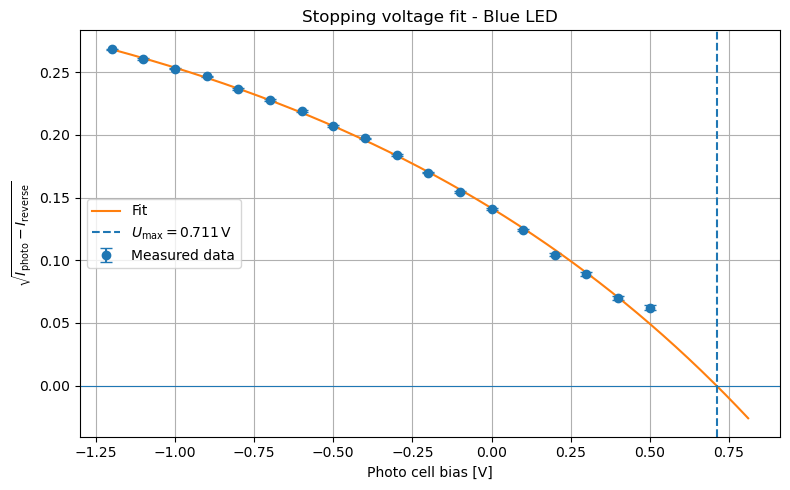

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# x-axis intercept = stopping voltage
# ------------------------------------------------

U_stopping_blue = A + np.log(C) / np.log(B)

print(f"Stopping voltage U_max = {U_stopping_blue:.4f} V")


# ------------------------------------------------
# Smooth x-values for fit curve
# Extend range so that x-axis intercept is visible
# ------------------------------------------------

x_min = np.min(bias[fit_mask])
x_max = max(np.max(bias[fit_mask]), U_stopping_blue + 0.1)

x_fit = np.linspace(x_min, x_max, 500)

# Fit curve
y_fit = fit_function(x_fit, A, B, C)


# ------------------------------------------------
# Plot
# ------------------------------------------------

plt.figure(figsize=(8, 5))

# Measured data with error bars
plt.errorbar(
    bias[fit_mask],
    sqrt_I_blue[fit_mask],
    yerr=sigma_fit[fit_mask],
    fmt='o',
    capsize=4,
    label='Measured data'
)

# Fit curve
plt.plot(
    x_fit,
    y_fit,
    label='Fit'
)

# Vertical line at stopping voltage
plt.axvline(
    U_stopping_blue,
    linestyle='--',
    label=rf'$U_{{\max}} = {U_stopping_blue:.3f}\,\mathrm{{V}}$'
)

# Horizontal x-axis
plt.axhline(
    0,
    linewidth=0.8
)

plt.xlabel('Photo cell bias [V]')
plt.ylabel(r'$\sqrt{I_{\mathrm{photo}} - I_{\mathrm{reverse}}}$')
plt.title('Stopping voltage fit - Blue LED')

plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig(
    "Plots/Fit_Ustop_blue.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

# Fit U_stop für Green

In [31]:
from scipy.optimize import curve_fit

def fit_function(x,A,B,C):
    return C - B ** (x-A)

U_max=0.5
fit_mask = (
    (bias <= U_max)
    & (sqrt_I_green > 0)
    & np.isfinite(sqrt_I_green)

)



sigma_Uout = 0.001      # z.B. 1 mV
sigma_I_photo = sigma_Uout / 10

sigma_I_corr = np.sqrt(
    sigma_I_photo**2
    + sigma_reverse_green**2
)



sigma_fit = sigma_I_corr / (2 * sqrt_I_green)


popt, pcov = curve_fit(
    fit_function,
    bias[fit_mask],
    sqrt_I_green[fit_mask],
    sigma=sigma_fit[fit_mask],
    absolute_sigma=True,
    p0=[1, 2, 0.3],
    maxfev=20000
)

A, B, C = popt
sigma_A_g, sigma_B_G, sigma_C_g = np.sqrt(np.diag(pcov))


y_model = fit_function(bias[fit_mask], A, B, C)


residuals = sqrt_I_green[fit_mask] - y_model


chi_square = np.sum(
    (residuals / sigma_fit[fit_mask])**2
)

N = np.sum(fit_mask)


n_parameters = 3


dof = N - n_parameters

chi_square_red = chi_square / dof

print(f"Chi-square         = {chi_square:.4f}")
print(f"Degrees of freedom = {dof}")
print(f"Reduced chi-square = {chi_square_red:.4f}")


grad = np.array([
    1.0,
    -np.log(C) / (B * np.log(B)**2),
    1.0 / (C * np.log(B))
])


sigma_U_stopping_green = np.sqrt(
    grad @ pcov @ grad
)

Chi-square         = 90.3187
Degrees of freedom = 14
Reduced chi-square = 6.4513


Stopping voltage U_max = 0.5238 V


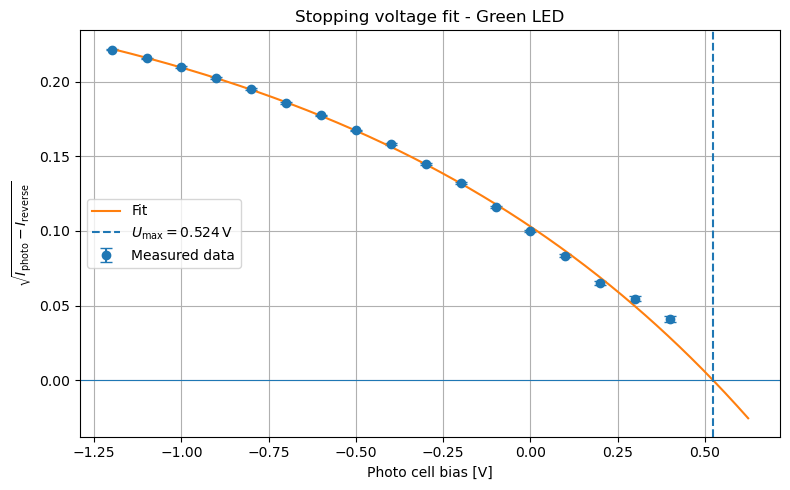

In [32]:
import numpy as np
import matplotlib.pyplot as plt


U_stopping_green = A + np.log(C) / np.log(B)

print(f"Stopping voltage U_max = {U_stopping_green:.4f} V")



x_min = np.min(bias[fit_mask])
x_max = max(np.max(bias[fit_mask]), U_stopping_green + 0.1)

x_fit = np.linspace(x_min, x_max, 500)

y_fit = fit_function(x_fit, A, B, C)




plt.figure(figsize=(8, 5))


plt.errorbar(
    bias[fit_mask],
    sqrt_I_green[fit_mask],
    yerr=sigma_fit[fit_mask],
    fmt='o',
    capsize=4,
    label='Measured data'
)


plt.plot(
    x_fit,
    y_fit,
    label='Fit'
)


plt.axvline(
    U_stopping_green,
    linestyle='--',
    label=rf'$U_{{\max}} = {U_stopping_green:.3f}\,\mathrm{{V}}$'
)

plt.axhline(
    0,
    linewidth=0.8
)

plt.xlabel('Photo cell bias [V]')
plt.ylabel(r'$\sqrt{I_{\mathrm{photo}} - I_{\mathrm{reverse}}}$')
plt.title('Stopping voltage fit - Green LED')

plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig(
    "Plots/Fit_Ustop_green.png",
    dpi=180,
    bbox_inches="tight"
)
plt.show()

# Fit für U_stop yellow

In [33]:
from scipy.optimize import curve_fit

def fit_function(x,A,B,C):
    return C - B ** (x-A)

U_max=0.5
fit_mask = (
    (bias <= U_max)
    & (sqrt_I_yellow > 0)
    & np.isfinite(sqrt_I_yellow)
)




sigma_Uout = 0.001      # z.B. 1 mV
sigma_I_photo = sigma_Uout / 10

sigma_I_corr = np.sqrt(
    sigma_I_photo**2
    + sigma_reverse_yellow**2
)




sigma_fit = sigma_I_corr / (2 * sqrt_I_yellow)

popt, pcov = curve_fit(
    fit_function,
    bias[fit_mask],
    sqrt_I_yellow[fit_mask],
    sigma=sigma_fit[fit_mask],
    absolute_sigma=True,
    p0=[1, 2, 0.3],
    maxfev=20000
)

A, B, C = popt
sigma_A_y, sigma_B_y, sigma_C_y = np.sqrt(np.diag(pcov))


y_model = fit_function(bias[fit_mask], A, B, C)


residuals = sqrt_I_yellow[fit_mask] - y_model


chi_square = np.sum(
    (residuals / sigma_fit[fit_mask])**2
)

N = np.sum(fit_mask)


n_parameters = 3


dof = N - n_parameters


chi_square_red = chi_square / dof

print(f"Chi-square         = {chi_square:.4f}")
print(f"Degrees of freedom = {dof}")
print(f"Reduced chi-square = {chi_square_red:.4f}")


grad = np.array([
    1.0,
    -np.log(C) / (B * np.log(B)**2),
    1.0 / (C * np.log(B))
])


sigma_U_stopping_yellow = np.sqrt(
    grad @ pcov @ grad
)

Chi-square         = 35.2259
Degrees of freedom = 14
Reduced chi-square = 2.5161


Stopping voltage U_max = 0.3993 V


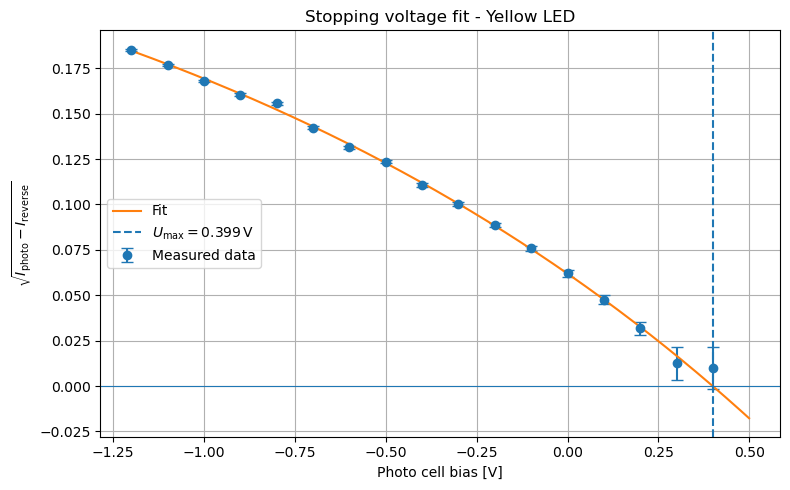

In [34]:
import numpy as np
import matplotlib.pyplot as plt



U_stopping_yellow = A + np.log(C) / np.log(B)

print(f"Stopping voltage U_max = {U_stopping_yellow:.4f} V")



x_min = np.min(bias[fit_mask])
x_max = max(np.max(bias[fit_mask]), U_stopping_yellow + 0.1)

x_fit = np.linspace(x_min, x_max, 500)

y_fit = fit_function(x_fit, A, B, C)




plt.figure(figsize=(8, 5))


plt.errorbar(
    bias[fit_mask],
    sqrt_I_yellow[fit_mask],
    yerr=sigma_fit[fit_mask],
    fmt='o',
    capsize=4,
    label='Measured data'
)


plt.plot(
    x_fit,
    y_fit,
    label='Fit'
)

plt.axvline(
    U_stopping_yellow,
    linestyle='--',
    label=rf'$U_{{\max}} = {U_stopping_yellow:.3f}\,\mathrm{{V}}$'
)


plt.axhline(
    0,
    linewidth=0.8
)

plt.xlabel('Photo cell bias [V]')
plt.ylabel(r'$\sqrt{I_{\mathrm{photo}} - I_{\mathrm{reverse}}}$')
plt.title('Stopping voltage fit - Yellow LED')

plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig(
    "Plots/Fit_Ustop_yellow.png",
    dpi=180,
    bbox_inches="tight"
)
plt.show()

# Fit für U_stop red

In [35]:
from scipy.optimize import curve_fit


def fit_function(x,A,B,C):
    return C - B ** (x-A)

U_max=0.5
fit_mask = (bias <= U_max)
   


sigma_Uout = 0.001      
sigma_I_photo = sigma_Uout / 10

sigma_I_corr = np.sqrt(
    sigma_I_photo**2
    + sigma_reverse_red**2
)

sigma_fit = sigma_I_corr / (2 * sqrt_I_red)

popt, pcov = curve_fit(
    fit_function,
    bias[fit_mask],
    sqrt_I_red[fit_mask],
    sigma=sigma_fit[fit_mask],
    absolute_sigma=True,
    p0=[1, 2, 0.3],
    maxfev=20000
)

A, B, C = popt
sigma_A_r, sigma_B_r, sigma_C_r = np.sqrt(np.diag(pcov))


y_model = fit_function(bias[fit_mask], A, B, C)


residuals = sqrt_I_red[fit_mask] - y_model


chi_square = np.sum(
    (residuals / sigma_fit[fit_mask])**2
)


N = np.sum(fit_mask)


n_parameters = 3

dof = N - n_parameters


chi_square_red = chi_square / dof

print(f"Chi-square         = {chi_square:.4f}")
print(f"Degrees of freedom = {dof}")
print(f"Reduced chi-square = {chi_square_red:.4f}")


grad = np.array([
    1.0,
    -np.log(C) / (B * np.log(B)**2),
    1.0 / (C * np.log(B))
])


sigma_U_stopping_red = np.sqrt(
    grad @ pcov @ grad
)

Chi-square         = 14.9415
Degrees of freedom = 14
Reduced chi-square = 1.0672


Stopping voltage U_max = 0.3585 V


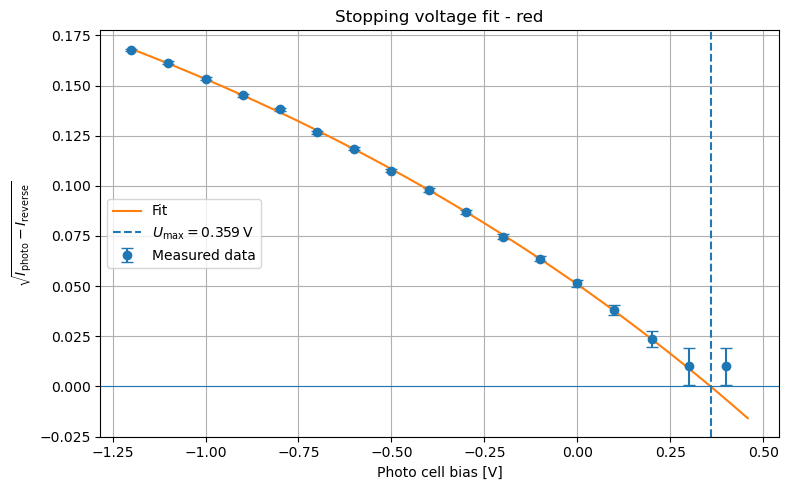

In [36]:
import numpy as np
import matplotlib.pyplot as plt


U_stopping_red = A + np.log(C) / np.log(B)

print(f"Stopping voltage U_max = {U_stopping_red:.4f} V")



x_min = np.min(bias[fit_mask])
x_max = max(np.max(bias[fit_mask]), U_stopping_red + 0.1)

x_fit = np.linspace(x_min, x_max, 500)


y_fit = fit_function(x_fit, A, B, C)



plt.figure(figsize=(8, 5))


plt.errorbar(
    bias[fit_mask],
    sqrt_I_red[fit_mask],
    yerr=sigma_fit[fit_mask],
    fmt='o',
    capsize=4,
    label='Measured data'
)

plt.plot(
    x_fit,
    y_fit,
    label='Fit'
)


plt.axvline(
    U_stopping_red,
    linestyle='--',
    label=rf'$U_{{\max}} = {U_stopping_red:.3f}\,\mathrm{{V}}$'
)


plt.axhline(
    0,
    linewidth=0.8
)

plt.xlabel('Photo cell bias [V]')
plt.ylabel(r'$\sqrt{I_{\mathrm{photo}} - I_{\mathrm{reverse}}}$')
plt.title('Stopping voltage fit - red')

plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig(
    "Plots/Fit_Ustop_red.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

# Millikan’s curve getting the constans

a = 3.231e-15 +/- 3.075e-16 V s
b = -1.236e+00 +/- 1.620e-01 V
h = 5.176e-34 +/- 4.926e-35 J s
W = 1.980e-19 +/- 2.595e-20 J
W = 1.236 +/- 0.162 eV


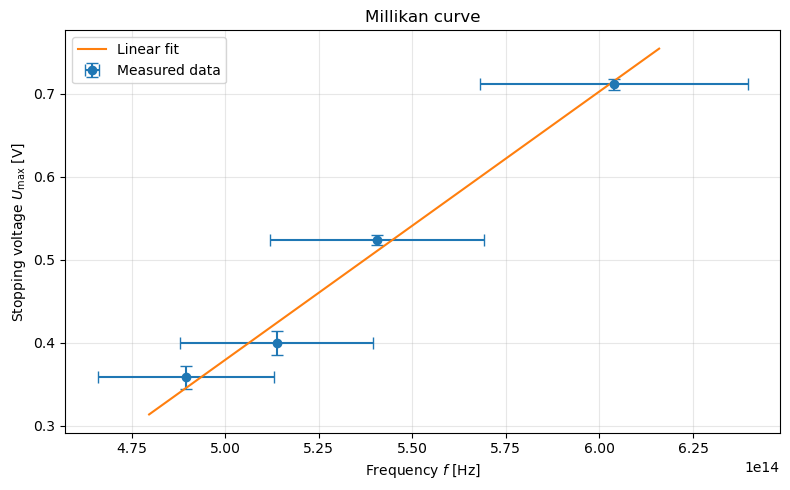

[0.01362203 0.01447092 0.00599059 0.00703206]


In [37]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.constants import c, e
from scipy.odr import ODR, Model, RealData




wavelengths = np.array([
    wave_length_red,
    wave_length_yellow,
    wave_length_green,
    wave_length_blue
])

sigma_wavelengths = np.array([
    sigma_red,
    sigma_yellow,
    sigma_green,
    sigma_blue
])



f = c / wavelengths

df = c / wavelengths**2 * sigma_wavelengths



U_stop = np.array([
    U_stopping_red,
    U_stopping_yellow,
    U_stopping_green,
    U_stopping_blue
])





dU = np.array([
    sigma_U_stopping_red,
    sigma_U_stopping_yellow,
    sigma_U_stopping_green,
    sigma_U_stopping_blue
])


def fit_function(beta, x):
    a, b = beta
    return a * x + b


data = RealData(
    f,
    U_stop,
    sx=df,
    sy=dU
)

model = Model(fit_function)

out = ODR(
    data,
    model,
    beta0=[4e-15, -2]
).run()


a, b = out.beta
da, db = out.sd_beta




h_exp = a * e
dh_exp = da * e

W_J = -b * e
dW_J = db * e

# Work function in eV
W_eV = -b
dW_eV = db


print(f"a = {a:.3e} +/- {da:.3e} V s")
print(f"b = {b:.3e} +/- {db:.3e} V")

print(f"h = {h_exp:.3e} +/- {dh_exp:.3e} J s")
print(f"W = {W_J:.3e} +/- {dW_J:.3e} J")
print(f"W = {W_eV:.3f} +/- {dW_eV:.3f} eV")




x_fit = np.linspace(
    np.min(f) * 0.98,
    np.max(f) * 1.02,
    200
)

y_fit = fit_function(
    [a, b],
    x_fit
)

plt.figure(figsize=(8, 5))

plt.errorbar(
    f,
    U_stop,
    xerr=df,
    yerr=dU,
    fmt="o",
    capsize=4,
    label="Measured data"
)

plt.plot(
    x_fit,
    y_fit,
    label="Linear fit"
)

plt.xlabel("Frequency $f$ [Hz]")
plt.ylabel(r"Stopping voltage $U_{\max}$ [V]")
plt.title("Millikan curve")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(
    "Plots/Millikan_4_LED.png",
    dpi=180,
    bbox_inches="tight"
)
plt.show()
print(dU)

a = 3.231e-15 +/- 3.075e-16 V s
b = -1.236e+00 +/- 1.620e-01 V
h = 5.176e-34 +/- 4.926e-35 J s
W = 1.980e-19 +/- 2.595e-20 J
W = 1.236 +/- 0.162 eV


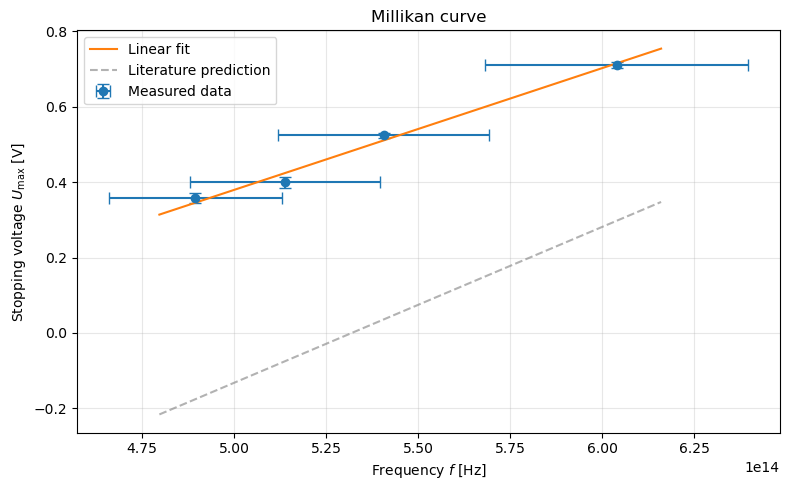

[0.01362203 0.01447092 0.00599059 0.00703206]


In [38]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.constants import c, e, h
from scipy.odr import ODR, Model, RealData




wavelengths = np.array([
    wave_length_red,
    wave_length_yellow,
    wave_length_green,
    wave_length_blue
])

sigma_wavelengths = np.array([
    sigma_red,
    sigma_yellow,
    sigma_green,
    sigma_blue
])




f = c / wavelengths

df = c / wavelengths**2 * sigma_wavelengths




U_stop = np.array([
    U_stopping_red,
    U_stopping_yellow,
    U_stopping_green,
    U_stopping_blue
])



dU = np.array([
    sigma_U_stopping_red,
    sigma_U_stopping_yellow,
    sigma_U_stopping_green,
    sigma_U_stopping_blue
])




def fit_function(beta, x):
    a, b = beta
    return a * x + b


data = RealData(
    f,
    U_stop,
    sx=df,
    sy=dU
)

model = Model(fit_function)

out = ODR(
    data,
    model,
    beta0=[4e-15, -2]
).run()


a, b = out.beta
da, db = out.sd_beta



h_exp = a * e
dh_exp = da * e

W_J = -b * e
dW_J = db * e

# Work function in eV
W_eV = -b
dW_eV = db


print(f"a = {a:.3e} +/- {da:.3e} V s")
print(f"b = {b:.3e} +/- {db:.3e} V")

print(f"h = {h_exp:.3e} +/- {dh_exp:.3e} J s")
print(f"W = {W_J:.3e} +/- {dW_J:.3e} J")
print(f"W = {W_eV:.3f} +/- {dW_eV:.3f} eV")




x_fit = np.linspace(
    np.min(f) * 0.98,
    np.max(f) * 1.02,
    200
)

y_fit = fit_function(
    [a, b],
    x_fit
)



W_lit_eV = 2.2

y_lit = (h / e) * x_fit - W_lit_eV


plt.figure(figsize=(8, 5))

plt.errorbar(
    f,
    U_stop,
    xerr=df,
    yerr=dU,
    fmt="o",
    capsize=4,
    label="Measured data"
)

plt.plot(
    x_fit,
    y_fit,
    label="Linear fit"
)

plt.plot(
    x_fit,
    y_lit,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    alpha=0.6,
    label="Literature prediction"
)

plt.xlabel("Frequency $f$ [Hz]")
plt.ylabel(r"Stopping voltage $U_{\max}$ [V]")
plt.title("Millikan curve")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()


plt.savefig(
    "Plots/Millikan_with_prediction.png",
    dpi=180,
    bbox_inches="tight"
)
plt.show()

print(dU)